# Matching track


<br/>
<div class="alert alert-block alert-info" style="padding:1em">
    
```python
  collection = tkl.XXXX
```

</div>

## As usual, let's start by defining our environment

The first task is only useful for the online notebook and import the local tracklib code source. It's not necessary if tracklib is installed from PyPI.

In [1]:
import os
import sys

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

The following two imports are necessary for the tutorial:

In [11]:
import math

# Matplotlib to create visualizations
import matplotlib.pyplot as plt

# Import tracklib library
import tracklib as tkl

## Loading a collection of tracks and Profile of difference between two traces

with DTW (Dynamic Time Warping) method

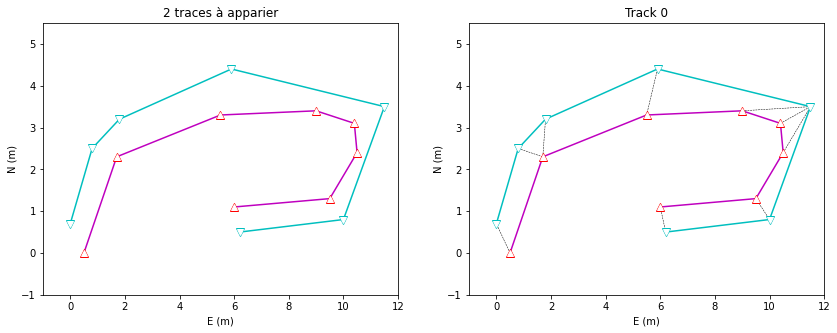

In [9]:
tkl.ObsTime.setReadFormat("4Y-2M-2D 2h:2m:2s")

plt.figure(figsize=(14, 5))


ax1 = plt.subplot2grid((1, 2), (0, 0))
chemin1 = '../../../test/data/compare/dtw1.csv'
trace1 = tkl.TrackReader.readFromCsv(chemin1, 0, 1, 2, 3, separator=",",read_all=True, h=1)
trace1gr = trace1.copy()
trace1gr.plot('m-', append=ax1)
trace1.plotAsMarkers(type=tkl.MARKERS_TYPE_WARNING, append=ax1)

chemin2 = '../../../test/data/compare/dtw2.csv'
trace2 = tkl.TrackReader.readFromCsv(chemin2, 0, 1, 2, 3, separator=",",read_all=True, h=1)
trace2.plot('c-', append=ax1)
trace2.plotAsMarkers(bkg='w', frg='c', sym_frg = " ", sym_bkg = "v", append=ax1)

ax1.set_title('2 traces à apparier')
ax1.set_xlim(-1, 12)
plt.ylim([-1, 5.5])

# ----

ax2 = plt.subplot2grid((1, 2), (0, 1))

mode = tkl.MODE_MATCHING_DTW
p = 2
dim = 2

profile = tkl.match(trace1, trace2, mode=mode, p=p, dim=dim, verbose=False, plot=False)
tkl.plotMatching(profile, trace2, append=ax2)

trace1gr.plot('m-', append=ax2)
trace1.plotAsMarkers(type=tkl.MARKERS_TYPE_WARNING, append=ax2)
trace2.plot('c-', append=ax2)
trace2.plotAsMarkers(bkg='w', frg='c', sym_frg = " ", sym_bkg = "v", append=ax2)

# ----

plt.xlim([-1, 12])
plt.ylim([-1, 5.5])
plt.show()

## Un cas plus complex

Generated track from 18/05/2028 22:31:24 to 18/05/2028 23:31:24 [100 pts, 2687.54m]
Generated track from 28/05/2017 10:29:10 to 28/05/2017 11:29:10 [100 pts, 2514.33m]


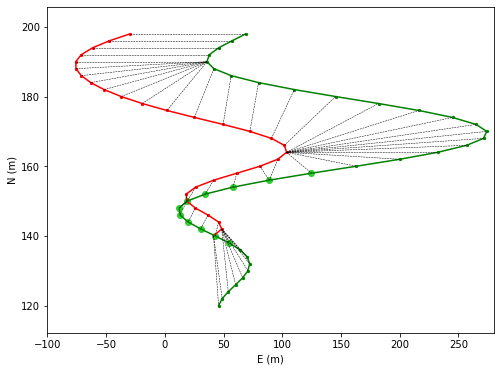

In [17]:
plt.figure(figsize=(8, 6))


tkl.stochastics.seed(122)
sentier1 = tkl.synthetics.generate(kernel=tkl.SincKernel(7))
sentier1["y"] = lambda track, i : i*2
tkl.computeAbsCurv(sentier1)
sentier1["z"] = lambda track, i : track["abs_curv", i]*math.atan(10*math.pi/180)
sentier1 = sentier1[70:]
sentier1.plot('r-', append=True)
sentier1.plot('ro', append=True)

sentier2 = tkl.synthetics.generate(kernel=tkl.SincKernel(7.2))
sentier2["y"] = lambda track, i : i*2
tkl.computeAbsCurv(sentier2)
sentier2["z"] = lambda track, i : track["abs_curv", i]*math.atan(10*math.pi/180)
sentier2 = sentier2[70:]
sentier2.plot('g-', append=True)
sentier2.plot('go', append=True)


t22 = sentier2.extract(9,19)
plt.scatter(t22.getX(), t22.getY(), color='limegreen')


mode = tkl.MODE_MATCHING_DTW
p = 2
profile = tkl.match(sentier1, sentier2, mode=mode, p=p,
                    dim=2, verbose=False, plot=False)
tkl.plotMatching(profile, sentier2, append=True)

plt.title("")
plt.xlim([-100, 280])
#plt.ylim([140, 200])
plt.show()